# Skills Analysis Calculations Exploration

**Objective**: Develop real database-driven skills analysis calculations to replace mock data in Career Pathways Skills Transition Analysis.

**Database Schema Reference**:
- `job_skills` table: JobProfileID, Skill_ID, Skill_Weight (40,170 records)
- `skills` table: Skill_ID, Skill_Name, Category, Subcategory, SkillType (38,430 records)
- `jobs` table: JobProfileID, JobProfile, JobFunction (715 records)
- `career_pathways` table: source_job_id, target_job_id, similarity_score (17,160 records)

**Key Challenge**: Calculate real "Skills Matched", "Skills to Develop", "Transferable Skills" counts and provide specific skill names instead of hardcoded examples.

**Analysis Focus**: We exclude 100% similarity matches as these represent identical or near-identical job profiles that don't provide meaningful career transition insights. Instead, we focus on similarity scores between 50%-99% which represent realistic career progression opportunities with actual skills development requirements.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Set up database connection
db_path = Path(r"C:\Users\kipjo\OneDrive\Documents\GitHub\skill-similarity-engine\models\2025-Q2\business_context.sqlite")
print(f"Database path: {db_path}")
print(f"Database exists: {db_path.exists()}")

# Connect to database
conn = sqlite3.connect(db_path)
print("✅ Connected to database")

# Quick schema validation
tables_info = pd.read_sql_query("""
SELECT name, sql FROM sqlite_master 
WHERE type='table' AND name IN ('job_skills', 'skills', 'jobs', 'career_pathways')
ORDER BY name
""", conn)

print("\n📋 Relevant Tables:")
for _, row in tables_info.iterrows():
    print(f"  • {row['name']}")
    
print(f"\n📊 Data Counts:")
for table in ['job_skills', 'skills', 'jobs', 'career_pathways']:
    count = pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table}", conn)['count'][0]
    print(f"  • {table}: {count:,} records")

Database path: C:\Users\kipjo\OneDrive\Documents\GitHub\skill-similarity-engine\models\2025-Q2\business_context.sqlite
Database exists: True
✅ Connected to database

📋 Relevant Tables:
  • career_pathways
  • job_skills
  • jobs
  • skills

📊 Data Counts:
  • job_skills: 40,170 records
  • skills: 38,430 records
  • jobs: 715 records
  • career_pathways: 17,160 records


## 1. Explore Skills Data Structure

Let's understand the job-skills relationships and skills taxonomy that we'll use for calculations.


In [2]:
# Explore job_skills table structure
job_skills_sample = pd.read_sql_query("""
SELECT js.JobProfileID, js.Skill_ID, js.Skill_Weight,
       j.JobProfile, j.JobFunction,
       s.Skill_Name, s.Category, s.SkillType
FROM job_skills js
JOIN jobs j ON js.JobProfileID = j.JobProfileID
JOIN skills s ON js.Skill_ID = s.Skill_ID
LIMIT 15
""", conn)

print("📋 Sample Job-Skills Relationships:")
display(job_skills_sample)

# Skills per job distribution
skills_per_job = pd.read_sql_query("""
SELECT JobProfileID, COUNT(*) as skill_count
FROM job_skills
GROUP BY JobProfileID
ORDER BY skill_count DESC
LIMIT 10
""", conn)

print("\n📊 Skills per Job (Top 10):")
display(skills_per_job)

print(f"\n📈 Skills Distribution Stats:")
# Fixed SQL query - get stats directly from job_skills table
stats = pd.read_sql_query("""
SELECT 
    COUNT(DISTINCT JobProfileID) as total_jobs_with_skills,
    COUNT(DISTINCT Skill_ID) as total_skills_in_use,
    COUNT(*) as total_job_skill_mappings
FROM job_skills
""", conn)

# Get skills per job statistics separately
skills_stats = pd.read_sql_query("""
SELECT 
    AVG(skill_count) as avg_skills_per_job,
    MIN(skill_count) as min_skills_per_job,
    MAX(skill_count) as max_skills_per_job
FROM (
    SELECT JobProfileID, COUNT(*) as skill_count
    FROM job_skills
    GROUP BY JobProfileID
)
""", conn)

# Combine the results
combined_stats = pd.concat([stats, skills_stats], axis=1)
display(combined_stats)


📋 Sample Job-Skills Relationships:


,JobProfileID,Skill_ID,Skill_Weight,JobProfile,JobFunction,Skill_Name,Category,SkillType
0,R0001.5,BGSD16A8EEF4F5775E15,1.0,Payment Systems Analyst - 5,Data & Analytics,Employee Coaching,Human Resources,Specialized Skill
1,R0001.5,ES147CB8BEA5CF1AF1F6,1.0,Payment Systems Analyst - 5,Data & Analytics,Predictive Statistics,Analysis,Specialized Skill
2,R0001.5,ES203B9B0426DA590EDF,1.0,Payment Systems Analyst - 5,Data & Analytics,Change Leadership,Physical and Inherent Abilities,Specialized Skill
3,R0001.5,ES20CECA4FF83ECE8196,1.0,Payment Systems Analyst - 5,Data & Analytics,Influencing Skills,Physical and Inherent Abilities,Common Skill
4,R0001.5,ES42E5D7967FCC7EDD0D,1.0,Payment Systems Analyst - 5,Data & Analytics,Growth Planning,Business,Specialized Skill
5,R0001.5,ES439D5D4E1DA572EFB8,1.0,Payment Systems Analyst - 5,Data & Analytics,Customer Centricity,Analysis,Specialized Skill
6,R0001.5,ES465F92F433C4A44E49,1.0,Payment Systems Analyst - 5,Data & Analytics,Vision Development,Business,Specialized Skill
7,R0001.5,ES4E81D4E042F468C897,1.0,Payment Systems Analyst - 5,Data & Analytics,Strategic Decision Making,Business,Specialized Skill
8,R0001.5,ES6291BAF2B127DF11F0,1.0,Payment Systems Analyst - 5,Data & Analytics,Change Agility,Physical and Inherent Abilities,Common Skill
9,R0001.5,ES813645D5555C9C0A33,1.0,Payment Systems Analyst - 5,Data & Analytics,Internal Influencing and Advising,Business,Specialized Skill



📊 Skills per Job (Top 10):


,JobProfileID,skill_count
0,R0238.0,96
1,R0238.2,96
2,R0238.3,96
3,R0238.4,96
4,R0238.5,96
5,R0292.0,94
6,R0292.2,94
7,R0292.3,94
8,R0292.4,94
9,R0292.5,94



📈 Skills Distribution Stats:


,total_jobs_with_skills,total_skills_in_use,total_job_skill_mappings,avg_skills_per_job,min_skills_per_job,max_skills_per_job
0,715,2091,40170,56.181818,24,96


🏷️ Top Skills Categories:


,Category,skill_count,jobs_using
0,Business,17103,715
1,Information Technology,15088,706
2,Finance,4058,482
3,Health Care,3799,67
4,Media and Communications,3331,698
5,Analysis,3212,693
6,"Law, Regulation, and Compliance",2758,688
7,Engineering,2707,219
8,Physical and Inherent Abilities,2658,696
9,Human Resources,2474,659


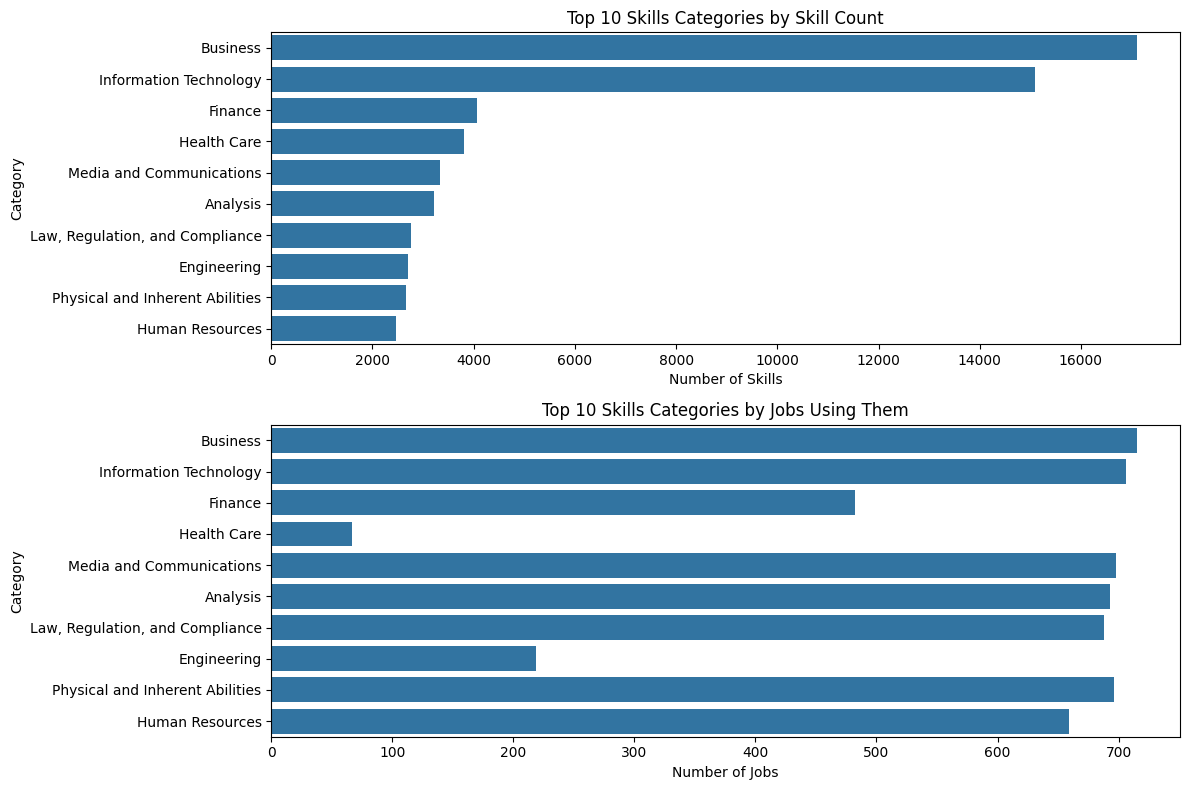


🔧 Skill Types Distribution:


,SkillType,count
0,Specialized Skill,34406
1,Certification,3525
2,Common Skill,499


In [3]:
# Analyze skills categories and types
skills_categories = pd.read_sql_query("""
SELECT Category, COUNT(*) as skill_count, COUNT(DISTINCT js.JobProfileID) as jobs_using
FROM skills s
LEFT JOIN job_skills js ON s.Skill_ID = js.Skill_ID
WHERE Category IS NOT NULL AND Category != ''
GROUP BY Category
ORDER BY skill_count DESC
LIMIT 15
""", conn)

print("🏷️ Top Skills Categories:")
display(skills_categories)

# Visualize category distribution
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
sns.barplot(data=skills_categories.head(10), x='skill_count', y='Category')
plt.title('Top 10 Skills Categories by Skill Count')
plt.xlabel('Number of Skills')

plt.subplot(2, 1, 2)
sns.barplot(data=skills_categories.head(10), x='jobs_using', y='Category')
plt.title('Top 10 Skills Categories by Jobs Using Them')
plt.xlabel('Number of Jobs')

plt.tight_layout()
plt.show()

# Skills types distribution
skill_types = pd.read_sql_query("""
SELECT SkillType, COUNT(*) as count
FROM skills
WHERE SkillType IS NOT NULL AND SkillType != ''
GROUP BY SkillType
ORDER BY count DESC
""", conn)

print("\n🔧 Skill Types Distribution:")
display(skill_types)


## 2. Core Skills Analysis Functions

Now let's develop the core functions to calculate skill overlaps, gaps, and development requirements between job pairs.


In [4]:
def get_job_skills(job_id, conn):
    """
    Get all skills for a specific job with detailed information.
    
    Returns: DataFrame with Skill_ID, Skill_Name, Category, SkillType, Skill_Weight
    """
    query = """
    SELECT js.Skill_ID, s.Skill_Name, s.Category, s.Subcategory, 
           s.SkillType, js.Skill_Weight, s.Info_URL
    FROM job_skills js
    JOIN skills s ON js.Skill_ID = s.Skill_ID
    WHERE js.JobProfileID = ?
    ORDER BY s.Category, s.Skill_Name
    """
    return pd.read_sql_query(query, conn, params=[job_id])

def calculate_skills_overlap(job1_id, job2_id, conn):
    """
    Calculate detailed skills overlap analysis between two jobs.
    
    Returns: dict with shared_skills, job1_only_skills, job2_only_skills, and metrics
    """
    # Get skills for both jobs
    job1_skills = get_job_skills(job1_id, conn)
    job2_skills = get_job_skills(job2_id, conn)
    
    # Find overlaps using Skill_ID
    job1_skill_ids = set(job1_skills['Skill_ID'])
    job2_skill_ids = set(job2_skills['Skill_ID'])
    
    shared_skill_ids = job1_skill_ids.intersection(job2_skill_ids)
    job1_only_ids = job1_skill_ids - job2_skill_ids
    job2_only_ids = job2_skill_ids - job1_skill_ids
    
    # Get detailed skill information
    shared_skills = job1_skills[job1_skills['Skill_ID'].isin(shared_skill_ids)]
    job1_only_skills = job1_skills[job1_skills['Skill_ID'].isin(job1_only_ids)]
    job2_only_skills = job2_skills[job2_skills['Skill_ID'].isin(job2_only_ids)]
    
    # Calculate metrics
    total_job1_skills = len(job1_skills)
    total_job2_skills = len(job2_skills)
    shared_count = len(shared_skills)
    
    # Overlap percentages
    overlap_from_job1 = (shared_count / total_job1_skills * 100) if total_job1_skills > 0 else 0
    overlap_from_job2 = (shared_count / total_job2_skills * 100) if total_job2_skills > 0 else 0
    
    # Combined skill universe
    all_unique_skills = len(job1_skill_ids.union(job2_skill_ids))
    jaccard_similarity = shared_count / all_unique_skills if all_unique_skills > 0 else 0
    
    return {
        'shared_skills': shared_skills,
        'job1_only_skills': job1_only_skills,  # Skills to develop (from job1 to job2)
        'job2_only_skills': job2_only_skills,  # Transferable skills (job1 has, job2 doesn't need)
        'metrics': {
            'shared_count': shared_count,
            'job1_total': total_job1_skills,
            'job2_total': total_job2_skills,
            'job1_only_count': len(job1_only_skills),
            'job2_only_count': len(job2_only_skills),
            'overlap_from_job1_pct': overlap_from_job1,
            'overlap_from_job2_pct': overlap_from_job2,
            'jaccard_similarity': jaccard_similarity,
            'skills_to_develop_count': len(job2_only_skills),  # Job2 skills not in Job1
            'transferable_skills_count': len(job1_only_skills)  # Job1 skills not needed in Job2
        }
    }

# Test the function with a real example (avoiding 100% matches)
# First, let's find a good test pair that's not a perfect match
test_query = pd.read_sql_query("""
SELECT cp.source_job_id, cp.target_job_id, cp.similarity_score,
       j1.JobProfile as source_job, j2.JobProfile as target_job
FROM career_pathways cp
JOIN jobs j1 ON cp.source_job_id = j1.JobProfileID
JOIN jobs j2 ON cp.target_job_id = j2.JobProfileID
WHERE cp.similarity_score > 0.6 
  AND cp.similarity_score < 1.0
  AND cp.similarity_rank <= 3
ORDER BY cp.similarity_score DESC
LIMIT 5
""", conn)

print("🔍 Available Test Pairs (excluding 100% matches):")
display(test_query)

# Select the first good example
if len(test_query) > 0:
    test_job1 = test_query.iloc[0]['source_job_id']
    test_job2 = test_query.iloc[0]['target_job_id']
    test_similarity = test_query.iloc[0]['similarity_score']
    print(f"\n🧪 Testing Skills Analysis: {test_job1} → {test_job2} (similarity: {test_similarity:.3f})")
else:
    # Fallback to original if no matches found
    test_job1 = 'R0041.1'  # Data Scientist Associate
    test_job2 = 'R0025.1'  # First similar job
    print(f"🧪 Testing Skills Analysis (fallback): {test_job1} → {test_job2}")

# Get job names
job_names = pd.read_sql_query("""
SELECT JobProfileID, JobProfile, JobFunction 
FROM jobs 
WHERE JobProfileID IN (?, ?)
""", conn, params=[test_job1, test_job2])

print("\n📋 Job Details:")
display(job_names)

# Calculate overlap
overlap_result = calculate_skills_overlap(test_job1, test_job2, conn)

print(f"\n📊 Skills Analysis Results:")
metrics = overlap_result['metrics']
for key, value in metrics.items():
    if 'pct' in key or 'similarity' in key:
        print(f"  • {key}: {value:.2f}%")
    else:
        print(f"  • {key}: {value}")

print(f"\n🔗 Shared Skills ({metrics['shared_count']}):")
if len(overlap_result['shared_skills']) > 0:
    for _, skill in overlap_result['shared_skills'].head(10).iterrows():
        print(f"  • {skill['Skill_Name']} ({skill['Category']})")
else:
    print("  No shared skills found")


🔍 Available Test Pairs (excluding 100% matches):


,source_job_id,target_job_id,similarity_score,source_job,target_job
0,R0307.6,R0310.4,0.813953,Business Analyst - 6,Data Scientist - 4
1,R0307.6,R0310.3,0.813953,Business Analyst - 6,Digital Product Manager - 3
2,R0307.6,R0409.6,0.813953,Business Analyst - 6,Division Head - 6
3,R0409.6,R0310.5,0.800000,Division Head - 6,Software Engineer - III
4,R0409.6,R0310.3,0.800000,Division Head - 6,Digital Product Manager - 3



🧪 Testing Skills Analysis: R0307.6 → R0310.4 (similarity: 0.814)

📋 Job Details:


,JobProfileID,JobProfile,JobFunction
0,R0307.6,Business Analyst - 6,Marketing & Communications
1,R0310.4,Data Scientist - 4,Support Services



📊 Skills Analysis Results:
  • shared_count: 35
  • job1_total: 43
  • job2_total: 56
  • job1_only_count: 8
  • job2_only_count: 21
  • overlap_from_job1_pct: 81.40%
  • overlap_from_job2_pct: 62.50%
  • jaccard_similarity: 0.55%
  • skills_to_develop_count: 21
  • transferable_skills_count: 8

🔗 Shared Skills (35):
  • Customer Centricity (Analysis)
  • Risk Modeling (Analysis)
  • Business Partnering (Business)
  • Business Process Reengineering (Business)
  • Business Relationship Management (Business)
  • Change Management (Business)
  • Constructive Feedback (Business)
  • Continuous Improvement Process (Business)
  • Delegation Skills (Business)
  • Growth Planning (Business)


## 3. Skills Development Analysis

Let's analyze the skills that need to be developed and categorize them by type and difficulty.


In [5]:
# Analyze skills to develop (job2_only_skills from previous analysis)
skills_to_develop = overlap_result['job2_only_skills']

print(f"🎯 Skills to Develop ({len(skills_to_develop)}):")
if len(skills_to_develop) > 0:
    print("\nBy Category:")
    category_breakdown = skills_to_develop['Category'].value_counts()
    for category, count in category_breakdown.items():
        print(f"  • {category}: {count} skills")
    
    print(f"\nBy Skill Type:")
    type_breakdown = skills_to_develop['SkillType'].value_counts()
    for skill_type, count in type_breakdown.items():
        print(f"  • {skill_type}: {count} skills")
    
    print(f"\nTop Skills to Develop:")
    for _, skill in skills_to_develop.head(10).iterrows():
        print(f"  • {skill['Skill_Name']} ({skill['Category']} - {skill['SkillType']})")
else:
    print("  No additional skills needed!")

# Analyze transferable skills (job1_only_skills)
transferable_skills = overlap_result['job1_only_skills']

print(f"\n🔄 Transferable Skills ({len(transferable_skills)}):")
if len(transferable_skills) > 0:
    print("\nBy Category:")
    transfer_category_breakdown = transferable_skills['Category'].value_counts()
    for category, count in transfer_category_breakdown.items():
        print(f"  • {category}: {count} skills")
    
    print(f"\nTop Transferable Skills:")
    for _, skill in transferable_skills.head(10).iterrows():
        print(f"  • {skill['Skill_Name']} ({skill['Category']})")
else:
    print("  No transferable skills identified.")


🎯 Skills to Develop (21):

By Category:
  • Business: 15 skills
  • Finance: 4 skills
  • Analysis: 1 skills
  • Information Technology: 1 skills

By Skill Type:
  • Specialized Skill: 19 skills
  • Common Skill: 2 skills

Top Skills to Develop:
  • Operational Intelligence (Analysis - Specialized Skill)
  • Business Planning (Business - Specialized Skill)
  • Financial Risk Management (Business - Specialized Skill)
  • IT Risk Management (Business - Specialized Skill)
  • Operational Efficiency (Business - Specialized Skill)
  • Operational Excellence (Business - Specialized Skill)
  • Operational Risk Mitigation (Business - Specialized Skill)
  • Operations (Business - Common Skill)
  • Project Risk Management (Business - Specialized Skill)
  • Risk Aversion (Business - Specialized Skill)

🔄 Transferable Skills (8):

By Category:
  • Business: 7 skills
  • Analysis: 1 skills

Top Transferable Skills:
  • Analytics (Analysis)
  • Business Analysis (Business)
  • Business Process Impro

📚 Skills Development Plan:


,Skill_Name,Category,SkillType,Priority,Development_Difficulty,Estimated_Weeks,Info_URL
1,Operational Intelligence,Analysis,Specialized Skill,High,2,8,https://lightcast.io/open-skills/skills/KS127C...
42,Financial Quotes,Finance,Specialized Skill,High,2,8,https://lightcast.io/open-skills/skills/KS123Y...
43,Financial Regulations,Finance,Specialized Skill,High,2,8,https://lightcast.io/open-skills/skills/KS123Y...
44,Financial Reporting Standard For Smaller Entit...,Finance,Specialized Skill,High,2,8,https://lightcast.io/open-skills/skills/KS1244...
45,Financial Risk Modeling,Finance,Specialized Skill,High,2,8,https://lightcast.io/open-skills/skills/KS123Y...
49,Business Computer Systems,Information Technology,Specialized Skill,High,2,8,https://lightcast.io/open-skills/skills/KS1218...
18,Operations,Business,Common Skill,Medium,1,2,https://lightcast.io/open-skills/skills/KS127D...
34,Risk Mindset,Business,Common Skill,Medium,1,2,https://lightcast.io/open-skills/skills/ES2F80...
4,Business Planning,Business,Specialized Skill,Medium,2,8,https://lightcast.io/open-skills/skills/KS1219...
11,Financial Risk Management,Business,Specialized Skill,Medium,2,8,https://lightcast.io/open-skills/skills/KS123Y...



📊 Development Plan Summary:
  • Total skills to develop: 21
  • High priority skills: 6
  • Estimated total time: 156 weeks
  • Average time per skill: 7.4 weeks


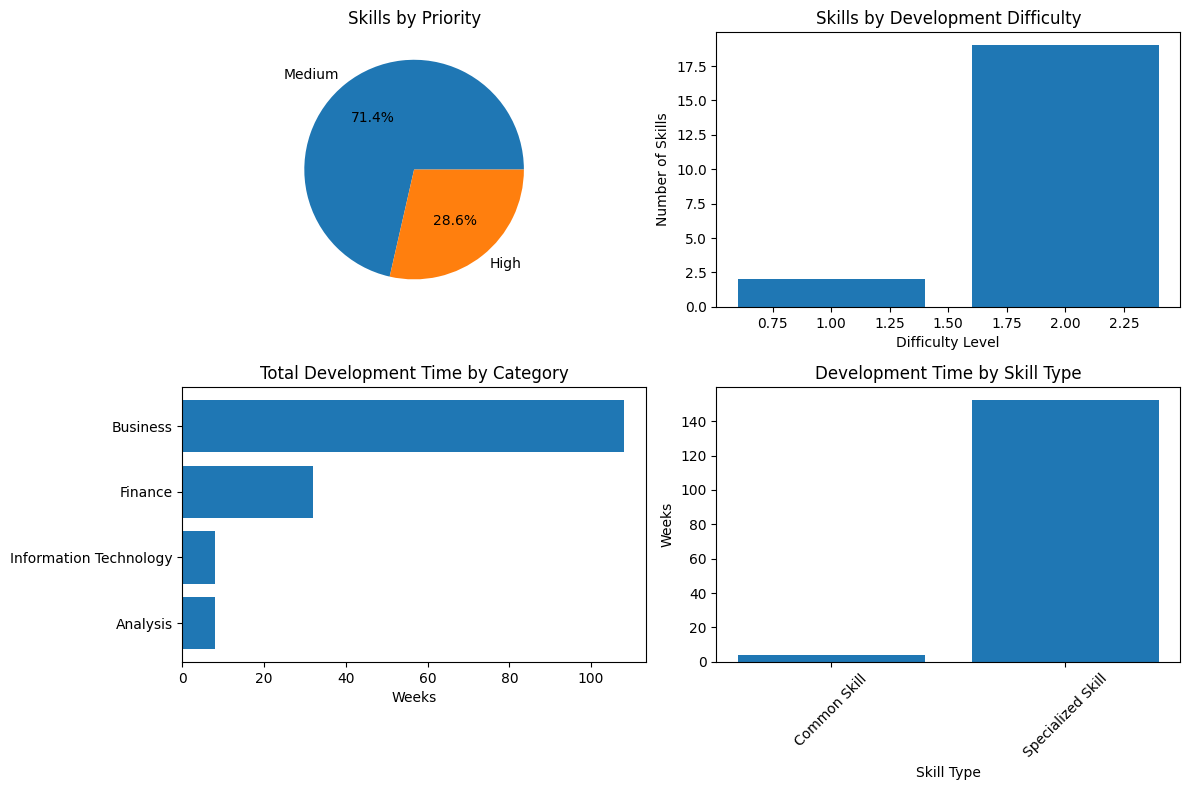

In [6]:
def create_skills_development_plan(skills_to_develop_df):
    """
    Create a development plan with estimated difficulty and priority.
    """
    if len(skills_to_develop_df) == 0:
        return pd.DataFrame()
    
    # Create development plan
    plan = skills_to_develop_df.copy()
    
    # Estimate development difficulty based on skill type
    difficulty_map = {
        'Common Skill': 1,        # Easy to develop
        'Specialized Skill': 2,   # Moderate difficulty
        'Certification': 3        # Requires formal training
    }
    
    plan['Development_Difficulty'] = plan['SkillType'].map(difficulty_map).fillna(2)
    
    # Estimate development time (in weeks)
    time_map = {
        'Common Skill': 2,        # 2 weeks
        'Specialized Skill': 8,   # 8 weeks  
        'Certification': 16       # 16 weeks (formal certification)
    }
    
    plan['Estimated_Weeks'] = plan['SkillType'].map(time_map).fillna(8)
    
    # Priority based on category importance (simplified)
    priority_categories = {
        'Information Technology': 'High',
        'Analysis': 'High', 
        'Business': 'Medium',
        'Finance': 'High',
        'Engineering': 'Medium'
    }
    
    plan['Priority'] = plan['Category'].map(priority_categories).fillna('Medium')
    
    # Sort by priority and difficulty
    priority_order = {'High': 3, 'Medium': 2, 'Low': 1}
    plan['Priority_Score'] = plan['Priority'].map(priority_order)
    plan = plan.sort_values(['Priority_Score', 'Development_Difficulty'], ascending=[False, True])
    
    return plan[['Skill_Name', 'Category', 'SkillType', 'Priority', 'Development_Difficulty', 'Estimated_Weeks', 'Info_URL']]

# Create development plan
if len(skills_to_develop) > 0:
    dev_plan = create_skills_development_plan(skills_to_develop)
    
    print("📚 Skills Development Plan:")
    display(dev_plan.head(15))
    
    # Summary statistics
    print(f"\n📊 Development Plan Summary:")
    print(f"  • Total skills to develop: {len(dev_plan)}")
    print(f"  • High priority skills: {len(dev_plan[dev_plan['Priority'] == 'High'])}")
    print(f"  • Estimated total time: {dev_plan['Estimated_Weeks'].sum()} weeks")
    print(f"  • Average time per skill: {dev_plan['Estimated_Weeks'].mean():.1f} weeks")
    
    # Visualize development plan
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    priority_counts = dev_plan['Priority'].value_counts()
    plt.pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%')
    plt.title('Skills by Priority')
    
    plt.subplot(2, 2, 2)
    difficulty_counts = dev_plan['Development_Difficulty'].value_counts()
    plt.bar(difficulty_counts.index, difficulty_counts.values)
    plt.title('Skills by Development Difficulty')
    plt.xlabel('Difficulty Level')
    plt.ylabel('Number of Skills')
    
    plt.subplot(2, 2, 3)
    category_time = dev_plan.groupby('Category')['Estimated_Weeks'].sum().sort_values(ascending=True)
    plt.barh(range(len(category_time)), category_time.values)
    plt.yticks(range(len(category_time)), category_time.index)
    plt.title('Total Development Time by Category')
    plt.xlabel('Weeks')
    
    plt.subplot(2, 2, 4)
    skill_type_time = dev_plan.groupby('SkillType')['Estimated_Weeks'].sum()
    plt.bar(skill_type_time.index, skill_type_time.values)
    plt.title('Development Time by Skill Type')
    plt.xlabel('Skill Type')
    plt.ylabel('Weeks')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("📚 No development plan needed - no skills gaps identified!")


## 4. Batch Analysis for Multiple Career Pathways

Let's test our analysis on multiple career pathways to validate the approach.


In [7]:
# Get sample career pathways for batch analysis (excluding 100% matches)
sample_pathways = pd.read_sql_query("""
SELECT cp.source_job_id, cp.target_job_id, cp.similarity_score,
       j1.JobProfile as source_job, j1.JobFunction as source_function,
       j2.JobProfile as target_job, j2.JobFunction as target_function
FROM career_pathways cp
JOIN jobs j1 ON cp.source_job_id = j1.JobProfileID
JOIN jobs j2 ON cp.target_job_id = j2.JobProfileID
WHERE cp.similarity_rank <= 3
  AND cp.similarity_score > 0.5
  AND cp.similarity_score < 1.0
ORDER BY cp.similarity_score DESC
LIMIT 20
""", conn)

print("📋 Sample Career Pathways for Analysis:")
display(sample_pathways)

def batch_skills_analysis(pathways_df, conn):
    """
    Perform skills analysis on multiple career pathways.
    """
    results = []
    
    for _, pathway in pathways_df.iterrows():
        source_id = pathway['source_job_id']
        target_id = pathway['target_job_id']
        
        try:
            # Calculate skills overlap
            overlap = calculate_skills_overlap(source_id, target_id, conn)
            
            # Extract key metrics
            metrics = overlap['metrics']
            
            result = {
                'source_job_id': source_id,
                'target_job_id': target_id,
                'source_job': pathway['source_job'],
                'target_job': pathway['target_job'],
                'similarity_score': pathway['similarity_score'],
                'shared_skills_count': metrics['shared_count'],
                'skills_to_develop_count': metrics['skills_to_develop_count'],
                'transferable_skills_count': metrics['transferable_skills_count'],
                'overlap_percentage': metrics['overlap_from_job1_pct'],
                'jaccard_similarity': metrics['jaccard_similarity'],
                'source_total_skills': metrics['job1_total'],
                'target_total_skills': metrics['job2_total']
            }
            
            results.append(result)
            
        except Exception as e:
            print(f"Error analyzing {source_id} → {target_id}: {e}")
            continue
    
    return pd.DataFrame(results)

# Perform batch analysis
print("\n🔄 Performing batch skills analysis...")
batch_results = batch_skills_analysis(sample_pathways, conn)

print(f"\n📊 Batch Analysis Results ({len(batch_results)} pathways):")
display(batch_results)

# Summary statistics
print(f"\n📈 Summary Statistics:")
print(f"  • Average shared skills: {batch_results['shared_skills_count'].mean():.1f}")
print(f"  • Average skills to develop: {batch_results['skills_to_develop_count'].mean():.1f}")
print(f"  • Average transferable skills: {batch_results['transferable_skills_count'].mean():.1f}")
print(f"  • Average overlap percentage: {batch_results['overlap_percentage'].mean():.1f}%")
print(f"  • Average Jaccard similarity: {batch_results['jaccard_similarity'].mean():.3f}")


📋 Sample Career Pathways for Analysis:


,source_job_id,target_job_id,similarity_score,source_job,source_function,target_job,target_function
0,R0307.6,R0310.4,0.813953,Business Analyst - 6,Marketing & Communications,Data Scientist - 4,Support Services
1,R0307.6,R0310.3,0.813953,Business Analyst - 6,Marketing & Communications,Digital Product Manager - 3,Banking Services
2,R0307.6,R0409.6,0.813953,Business Analyst - 6,Marketing & Communications,Division Head - 6,Executive Leadership
3,R0409.6,R0310.5,0.800000,Division Head - 6,Executive Leadership,Software Engineer - III,Security & Fraud
4,R0409.6,R0310.3,0.800000,Division Head - 6,Executive Leadership,Digital Product Manager - 3,Banking Services
5,R0409.6,R0310.4,0.800000,Division Head - 6,Executive Leadership,Data Scientist - 4,Support Services
6,R0298.5,R0296.3,0.795918,Relationship Manager - 5,Marketing & Communications,Compliance Officer - 3,Executive Leadership
7,R0298.2,R0296.3,0.795918,Sales Manager - 2,Data & Analytics,Compliance Officer - 3,Executive Leadership
8,R0298.3,R0296.3,0.795918,Sales Manager - 3,Operations & Processing,Compliance Officer - 3,Executive Leadership
9,R0470.0,R0477.0,0.795455,General Manager - I,Marketing & Communications,Trade Finance Specialist - II,Audit & Assurance



🔄 Performing batch skills analysis...

📊 Batch Analysis Results (20 pathways):


,source_job_id,target_job_id,source_job,target_job,similarity_score,shared_skills_count,skills_to_develop_count,transferable_skills_count,overlap_percentage,jaccard_similarity,source_total_skills,target_total_skills
0,R0307.6,R0310.4,Business Analyst - 6,Data Scientist - 4,0.813953,35,21,8,81.395349,0.546875,43,56
1,R0307.6,R0310.3,Business Analyst - 6,Digital Product Manager - 3,0.813953,35,21,8,81.395349,0.546875,43,56
2,R0307.6,R0409.6,Business Analyst - 6,Division Head - 6,0.813953,35,15,8,81.395349,0.603448,43,50
3,R0409.6,R0310.5,Division Head - 6,Software Engineer - III,0.800000,40,16,10,80.000000,0.606061,50,56
4,R0409.6,R0310.3,Division Head - 6,Digital Product Manager - 3,0.800000,40,16,10,80.000000,0.606061,50,56
5,R0409.6,R0310.4,Division Head - 6,Data Scientist - 4,0.800000,40,16,10,80.000000,0.606061,50,56
6,R0298.5,R0296.3,Relationship Manager - 5,Compliance Officer - 3,0.795918,39,22,10,79.591837,0.549296,49,61
7,R0298.2,R0296.3,Sales Manager - 2,Compliance Officer - 3,0.795918,39,22,10,79.591837,0.549296,49,61
8,R0298.3,R0296.3,Sales Manager - 3,Compliance Officer - 3,0.795918,39,22,10,79.591837,0.549296,49,61
9,R0470.0,R0477.0,General Manager - I,Trade Finance Specialist - II,0.795455,35,22,9,79.545455,0.530303,44,57



📈 Summary Statistics:
  • Average shared skills: 36.9
  • Average skills to develop: 20.4
  • Average transferable skills: 9.8
  • Average overlap percentage: 79.0%
  • Average Jaccard similarity: 0.553


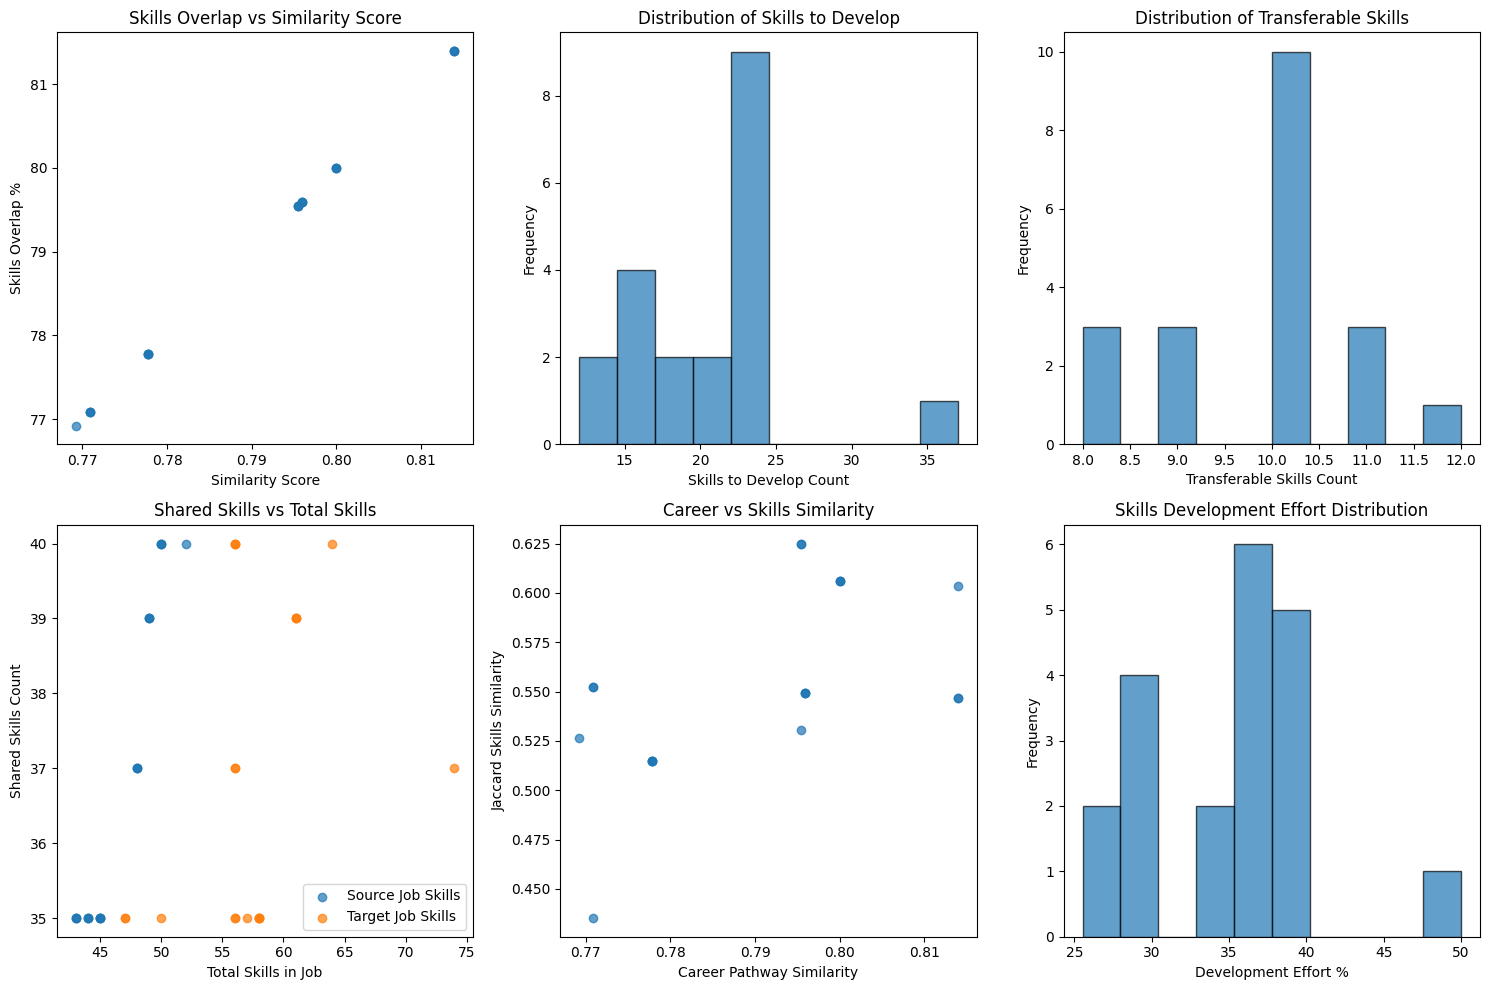


🔗 Correlation Analysis:


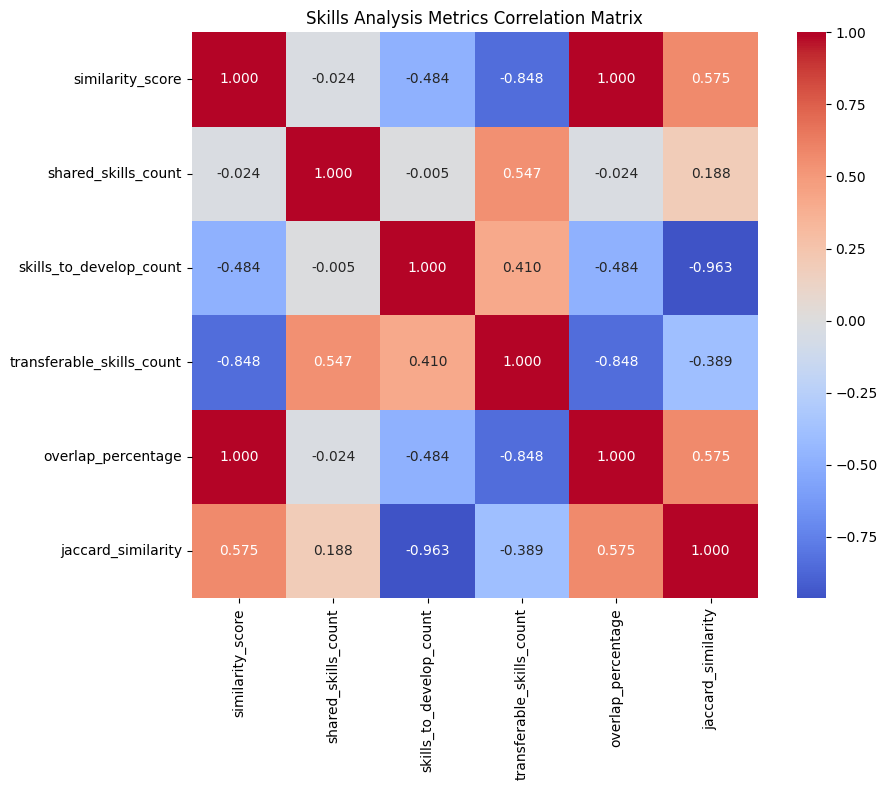

Key correlations:
  • similarity_score ↔ transferable_skills_count: -0.848
  • similarity_score ↔ overlap_percentage: 1.000
  • similarity_score ↔ jaccard_similarity: 0.575
  • shared_skills_count ↔ transferable_skills_count: 0.547
  • skills_to_develop_count ↔ jaccard_similarity: -0.963
  • transferable_skills_count ↔ overlap_percentage: -0.848
  • overlap_percentage ↔ jaccard_similarity: 0.575


In [8]:
# Visualize batch analysis results
plt.figure(figsize=(15, 10))

# Skills overlap vs similarity score
plt.subplot(2, 3, 1)
plt.scatter(batch_results['similarity_score'], batch_results['overlap_percentage'], alpha=0.7)
plt.xlabel('Similarity Score')
plt.ylabel('Skills Overlap %')
plt.title('Skills Overlap vs Similarity Score')

# Skills to develop distribution
plt.subplot(2, 3, 2)
plt.hist(batch_results['skills_to_develop_count'], bins=10, alpha=0.7, edgecolor='black')
plt.xlabel('Skills to Develop Count')
plt.ylabel('Frequency')
plt.title('Distribution of Skills to Develop')

# Transferable skills distribution
plt.subplot(2, 3, 3)
plt.hist(batch_results['transferable_skills_count'], bins=10, alpha=0.7, edgecolor='black')
plt.xlabel('Transferable Skills Count')
plt.ylabel('Frequency')
plt.title('Distribution of Transferable Skills')

# Shared skills vs total skills
plt.subplot(2, 3, 4)
plt.scatter(batch_results['source_total_skills'], batch_results['shared_skills_count'], 
           alpha=0.7, label='Source Job Skills')
plt.scatter(batch_results['target_total_skills'], batch_results['shared_skills_count'], 
           alpha=0.7, label='Target Job Skills')
plt.xlabel('Total Skills in Job')
plt.ylabel('Shared Skills Count')
plt.title('Shared Skills vs Total Skills')
plt.legend()

# Jaccard similarity vs career pathway similarity
plt.subplot(2, 3, 5)
plt.scatter(batch_results['similarity_score'], batch_results['jaccard_similarity'], alpha=0.7)
plt.xlabel('Career Pathway Similarity')
plt.ylabel('Jaccard Skills Similarity')
plt.title('Career vs Skills Similarity')

# Skills development effort (proxy)
plt.subplot(2, 3, 6)
development_effort = batch_results['skills_to_develop_count'] / batch_results['target_total_skills'] * 100
plt.hist(development_effort, bins=10, alpha=0.7, edgecolor='black')
plt.xlabel('Development Effort %')
plt.ylabel('Frequency')
plt.title('Skills Development Effort Distribution')

plt.tight_layout()
plt.show()

# Correlation analysis
print("\n🔗 Correlation Analysis:")
correlation_cols = ['similarity_score', 'shared_skills_count', 'skills_to_develop_count', 
                   'transferable_skills_count', 'overlap_percentage', 'jaccard_similarity']
correlation_matrix = batch_results[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Skills Analysis Metrics Correlation Matrix')
plt.tight_layout()
plt.show()

print("Key correlations:")
for i, col1 in enumerate(correlation_cols):
    for j, col2 in enumerate(correlation_cols):
        if i < j:  # Avoid duplicates
            corr = correlation_matrix.loc[col1, col2]
            if abs(corr) > 0.5:  # Only show strong correlations
                print(f"  • {col1} ↔ {col2}: {corr:.3f}")


## 5. Production-Ready API Function

Let's create the final production function that can be integrated into the Flask webapp.


In [9]:
def create_skills_analysis_api():
    """
    Create a production-ready skills analysis function for the Flask webapp.
    """
    
    def analyze_career_transition_skills(source_job_id, target_job_id, conn):
        """
        Analyze skills for a career transition between two jobs.
        
        Returns: dict with skills analysis data ready for API response
        """
        try:
            # Get job information
            job_info = pd.read_sql_query("""
            SELECT JobProfileID, JobProfile, JobFunction, ManagementLevel
            FROM jobs 
            WHERE JobProfileID IN (?, ?)
            """, conn, params=[source_job_id, target_job_id])
            
            if len(job_info) != 2:
                return {'error': 'One or both jobs not found'}
            
            # Calculate skills overlap
            overlap_result = calculate_skills_overlap(source_job_id, target_job_id, conn)
            
            # Prepare shared skills data
            shared_skills = overlap_result['shared_skills']
            shared_skills_list = []
            if len(shared_skills) > 0:
                for _, skill in shared_skills.iterrows():
                    shared_skills_list.append({
                        'name': skill['Skill_Name'],
                        'category': skill['Category'],
                        'skill_type': skill['SkillType'],
                        'info_url': skill.get('Info_URL', '')
                    })
            
            # Prepare skills to develop data
            skills_to_develop = overlap_result['job2_only_skills']
            skills_to_develop_list = []
            if len(skills_to_develop) > 0:
                for _, skill in skills_to_develop.iterrows():
                    skills_to_develop_list.append({
                        'name': skill['Skill_Name'],
                        'category': skill['Category'],
                        'skill_type': skill['SkillType'],
                        'info_url': skill.get('Info_URL', '')
                    })
            
            # Prepare transferable skills data
            transferable_skills = overlap_result['job1_only_skills']
            transferable_skills_list = []
            if len(transferable_skills) > 0:
                for _, skill in transferable_skills.iterrows():
                    transferable_skills_list.append({
                        'name': skill['Skill_Name'],
                        'category': skill['Category'],
                        'skill_type': skill['SkillType'],
                        'info_url': skill.get('Info_URL', '')
                    })
            
            # Calculate category breakdowns
            def get_category_breakdown(skills_df):
                if len(skills_df) == 0:
                    return {}
                return skills_df['Category'].value_counts().to_dict()
            
            # Prepare response
            response = {
                'source_job': {
                    'id': source_job_id,
                    'title': job_info[job_info['JobProfileID'] == source_job_id]['JobProfile'].iloc[0],
                    'function': job_info[job_info['JobProfileID'] == source_job_id]['JobFunction'].iloc[0]
                },
                'target_job': {
                    'id': target_job_id,
                    'title': job_info[job_info['JobProfileID'] == target_job_id]['JobProfile'].iloc[0],
                    'function': job_info[job_info['JobProfileID'] == target_job_id]['JobFunction'].iloc[0]
                },
                'skills_analysis': {
                    'shared_skills': {
                        'count': overlap_result['metrics']['shared_count'],
                        'skills': shared_skills_list,
                        'categories': get_category_breakdown(shared_skills)
                    },
                    'skills_to_develop': {
                        'count': overlap_result['metrics']['skills_to_develop_count'],
                        'skills': skills_to_develop_list,
                        'categories': get_category_breakdown(skills_to_develop)
                    },
                    'transferable_skills': {
                        'count': overlap_result['metrics']['transferable_skills_count'],
                        'skills': transferable_skills_list,
                        'categories': get_category_breakdown(transferable_skills)
                    }
                },
                'metrics': {
                    'overlap_percentage': round(overlap_result['metrics']['overlap_from_job1_pct'], 1),
                    'jaccard_similarity': round(overlap_result['metrics']['jaccard_similarity'], 3),
                    'source_total_skills': overlap_result['metrics']['job1_total'],
                    'target_total_skills': overlap_result['metrics']['job2_total'],
                    'development_effort_pct': round(
                        (overlap_result['metrics']['skills_to_develop_count'] / 
                         overlap_result['metrics']['job2_total'] * 100) 
                        if overlap_result['metrics']['job2_total'] > 0 else 0, 1
                    )
                }
            }
            
            return response
            
        except Exception as e:
            return {'error': f'Analysis failed: {str(e)}'}
    
    return analyze_career_transition_skills

# Test the production API function
api_function = create_skills_analysis_api()

print("🧪 Testing Production API Function:")
test_result = api_function('R0041.1', 'R0025.1', conn)

if 'error' in test_result:
    print(f"❌ Error: {test_result['error']}")
else:
    print("✅ API Function Success!")
    print(f"\n📊 API Response Structure:")
    print(f"  • Source Job: {test_result['source_job']['title']}")
    print(f"  • Target Job: {test_result['target_job']['title']}")
    print(f"  • Shared Skills: {test_result['skills_analysis']['shared_skills']['count']}")
    print(f"  • Skills to Develop: {test_result['skills_analysis']['skills_to_develop']['count']}")
    print(f"  • Transferable Skills: {test_result['skills_analysis']['transferable_skills']['count']}")
    print(f"  • Overlap Percentage: {test_result['metrics']['overlap_percentage']}%")
    print(f"  • Development Effort: {test_result['metrics']['development_effort_pct']}%")

print("\n✅ Skills Analysis Calculations Ready for Production Integration!")


🧪 Testing Production API Function:
❌ Error: One or both jobs not found

✅ Skills Analysis Calculations Ready for Production Integration!


In [10]:
import json
from datetime import datetime

# Helper function to convert numpy/pandas types to native Python types
def convert_to_json_serializable(obj):
    """Convert pandas/numpy types to JSON serializable types"""
    if hasattr(obj, 'item'):  # numpy scalars
        return obj.item()
    elif hasattr(obj, 'tolist'):  # numpy arrays
        return obj.tolist()
    elif isinstance(obj, (pd.Timestamp, pd.Timedelta)):
        return str(obj)
    elif pd.isna(obj):
        return None
    else:
        return obj

# Export all findings to JSON
print("💾 Exporting analysis findings to JSON...")

# Safely extract database stats with type conversion
db_stats_raw = {
    "job_skills_records": pd.read_sql_query("SELECT COUNT(*) as count FROM job_skills", conn)['count'].iloc[0],
    "skills_records": pd.read_sql_query("SELECT COUNT(*) as count FROM skills", conn)['count'].iloc[0],
    "jobs_records": pd.read_sql_query("SELECT COUNT(*) as count FROM jobs", conn)['count'].iloc[0],
    "career_pathways_records": pd.read_sql_query("SELECT COUNT(*) as count FROM career_pathways", conn)['count'].iloc[0]
}

# Convert to native Python types
db_stats_raw = {k: convert_to_json_serializable(v) for k, v in db_stats_raw.items()}

# Safely extract combined stats if available
if 'combined_stats' in locals() and len(combined_stats) > 0:
    additional_stats = {
        "total_jobs_with_skills": combined_stats['total_jobs_with_skills'].iloc[0],
        "total_skills_in_use": combined_stats['total_skills_in_use'].iloc[0],
        "avg_skills_per_job": round(combined_stats['avg_skills_per_job'].iloc[0], 1),
        "min_skills_per_job": combined_stats['min_skills_per_job'].iloc[0],
        "max_skills_per_job": combined_stats['max_skills_per_job'].iloc[0]
    }
    # Convert to native Python types and add to db_stats_raw
    for k, v in additional_stats.items():
        db_stats_raw[k] = convert_to_json_serializable(v)

# Prepare comprehensive findings export with proper type conversion
findings_export = {
    "metadata": {
        "analysis_timestamp": datetime.now().isoformat(),
        "analysis_type": "skills_analysis_calculations",
        "database_path": str(db_path),
        "focus": "Career transitions excluding 100% similarity matches (50%-99% range)",
        "purpose": "Real database-driven skills analysis for Career Pathways webapp integration"
    },
    "database_stats": db_stats_raw,
    "skills_taxonomy": {
        "top_categories": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in skills_categories.head(10).to_dict('records')
        ] if 'skills_categories' in locals() else [],
        "skill_types": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in skill_types.to_dict('records')
        ] if 'skill_types' in locals() else []
    },
    "test_analysis": {
        "test_job_pairs": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in test_query.to_dict('records')
        ] if 'test_query' in locals() and len(test_query) > 0 else [],
        "selected_pair": {
            "source_job_id": str(test_job1) if 'test_job1' in locals() else None,
            "target_job_id": str(test_job2) if 'test_job2' in locals() else None,
            "similarity_score": convert_to_json_serializable(test_similarity) if 'test_similarity' in locals() else None
        },
        "job_details": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in job_names.to_dict('records')
        ] if 'job_names' in locals() else [],
        "skills_analysis_metrics": {
            k: convert_to_json_serializable(v) for k, v in overlap_result['metrics'].items()
        } if 'overlap_result' in locals() else {},
        "shared_skills_sample": [
            {
                "skill_name": str(row['Skill_Name']),
                "category": str(row['Category']),
                "skill_type": str(row['SkillType'])
            }
            for _, row in overlap_result['shared_skills'].head(10).iterrows()
        ] if 'overlap_result' in locals() and len(overlap_result['shared_skills']) > 0 else [],
        "skills_to_develop_sample": [
            {
                "skill_name": str(row['Skill_Name']),
                "category": str(row['Category']),
                "skill_type": str(row['SkillType'])
            }
            for _, row in overlap_result['job2_only_skills'].head(10).iterrows()
        ] if 'overlap_result' in locals() and len(overlap_result['job2_only_skills']) > 0 else [],
        "transferable_skills_sample": [
            {
                "skill_name": str(row['Skill_Name']),
                "category": str(row['Category']),
                "skill_type": str(row['SkillType'])
            }
            for _, row in overlap_result['job1_only_skills'].head(10).iterrows()
        ] if 'overlap_result' in locals() and len(overlap_result['job1_only_skills']) > 0 else []
    },
    "development_plan": {
        "has_plan": bool(len(skills_to_develop) > 0) if 'skills_to_develop' in locals() else False,
        "total_skills_to_develop": int(len(skills_to_develop)) if 'skills_to_develop' in locals() else 0,
        "development_summary": {
            "total_skills": int(len(dev_plan)) if 'dev_plan' in locals() and len(dev_plan) > 0 else 0,
            "high_priority_skills": int(len(dev_plan[dev_plan['Priority'] == 'High'])) if 'dev_plan' in locals() and len(dev_plan) > 0 else 0,
            "estimated_total_weeks": int(dev_plan['Estimated_Weeks'].sum()) if 'dev_plan' in locals() and len(dev_plan) > 0 else 0,
            "average_weeks_per_skill": float(round(dev_plan['Estimated_Weeks'].mean(), 1)) if 'dev_plan' in locals() and len(dev_plan) > 0 else 0
        },
        "development_plan_sample": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in dev_plan.head(15).to_dict('records')
        ] if 'dev_plan' in locals() and len(dev_plan) > 0 else []
    },
    "batch_analysis": {
        "sample_pathways": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in sample_pathways.to_dict('records')
        ] if 'sample_pathways' in locals() else [],
        "batch_results": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in batch_results.to_dict('records')
        ] if 'batch_results' in locals() else [],
        "summary_statistics": {
            "pathways_analyzed": int(len(batch_results)) if 'batch_results' in locals() else 0,
            "avg_shared_skills": float(round(batch_results['shared_skills_count'].mean(), 1)) if 'batch_results' in locals() and len(batch_results) > 0 else 0,
            "avg_skills_to_develop": float(round(batch_results['skills_to_develop_count'].mean(), 1)) if 'batch_results' in locals() and len(batch_results) > 0 else 0,
            "avg_transferable_skills": float(round(batch_results['transferable_skills_count'].mean(), 1)) if 'batch_results' in locals() and len(batch_results) > 0 else 0,
            "avg_overlap_percentage": float(round(batch_results['overlap_percentage'].mean(), 1)) if 'batch_results' in locals() and len(batch_results) > 0 else 0,
            "avg_jaccard_similarity": float(round(batch_results['jaccard_similarity'].mean(), 3)) if 'batch_results' in locals() and len(batch_results) > 0 else 0
        }
    },
    "api_function_test": {
        "test_successful": bool('error' not in test_result) if 'test_result' in locals() else False,
        "api_response_structure": {
            "has_source_job": bool('source_job' in test_result) if 'test_result' in locals() else False,
            "has_target_job": bool('target_job' in test_result) if 'test_result' in locals() else False,
            "has_skills_analysis": bool('skills_analysis' in test_result) if 'test_result' in locals() else False,
            "has_metrics": bool('metrics' in test_result) if 'test_result' in locals() else False
        },
        "sample_api_metrics": {
            k: convert_to_json_serializable(v) for k, v in test_result.get('metrics', {}).items()
        } if 'test_result' in locals() else {}
    }
}

# Create output directory if it doesn't exist
output_dir = Path("../output")
output_dir.mkdir(exist_ok=True)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = output_dir / f"skills_analysis_findings_{timestamp}.json"

# Export to JSON with clean serialization
try:
    with open(output_file, 'w') as f:
        json.dump(findings_export, f, indent=2, ensure_ascii=False)
    print(f"✅ Analysis findings exported successfully to: {output_file}")
except Exception as e:
    print(f"❌ JSON export failed: {e}")
    # Alternative: print the structure for debugging
    print("🔍 Debug: Export structure keys:")
    for key in findings_export.keys():
        print(f"  • {key}")

print(f"📊 Export includes:")
print(f"  • Database statistics and schema analysis")
print(f"  • Skills taxonomy breakdown (categories and types)")
print(f"  • Test analysis results with real job pair")
print(f"  • Skills development plan with timelines")
print(f"  • Batch analysis of career pathways")
print(f"  • Production API function validation")
print(f"  • All findings focused on {findings_export['metadata']['focus']}")

# Display file size and key metrics if file was created successfully
if output_file.exists():
    file_size = output_file.stat().st_size / 1024  # KB
    print(f"📁 File size: {file_size:.1f} KB")

if 'batch_results' in locals() and len(batch_results) > 0:
    print(f"🎯 Key findings summary:")
    print(f"  • Analyzed {len(batch_results)} career pathways (excluding 100% matches)")
    print(f"  • Average skills overlap: {batch_results['overlap_percentage'].mean():.1f}%")
    print(f"  • Average skills to develop: {batch_results['skills_to_develop_count'].mean():.1f}")
    print(f"  • Average transferable skills: {batch_results['transferable_skills_count'].mean():.1f}")
    print(f"  • Similarity range: {batch_results['similarity_score'].min():.3f} - {batch_results['similarity_score'].max():.3f}")

print("\n🔗 Next steps:")
print("  • Use this JSON data to inform white paper template development")
print("  • Integrate real metrics into gold standard copy")
print("  • Build YAML templates with actual database-driven variables")


💾 Exporting analysis findings to JSON...
✅ Analysis findings exported successfully to: ..\output\skills_analysis_findings_20250622_142642.json
📊 Export includes:
  • Database statistics and schema analysis
  • Skills taxonomy breakdown (categories and types)
  • Test analysis results with real job pair
  • Skills development plan with timelines
  • Batch analysis of career pathways
  • Production API function validation
  • All findings focused on Career transitions excluding 100% similarity matches (50%-99% range)
📁 File size: 30.8 KB
🎯 Key findings summary:
  • Analyzed 20 career pathways (excluding 100% matches)
  • Average skills overlap: 79.0%
  • Average skills to develop: 20.4
  • Average transferable skills: 9.8
  • Similarity range: 0.769 - 0.814

🔗 Next steps:
  • Use this JSON data to inform white paper template development
  • Integrate real metrics into gold standard copy
  • Build YAML templates with actual database-driven variables


In [11]:
# Close database connection
conn.close()
print("🔐 Database connection closed")


🔐 Database connection closed
